In [15]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sleio import sle_io
from subprocess import Popen, PIPE
from multiprocessing import Pool

# Forward simulation Test

## Frontend input

In [2]:
# Simulation control (unit: mm, sec)
project_name = 'test_0710'
forward_dir = os.path.join(os.getcwd(), 'test_forward')
simulation_control = ('3D', 'steady', 'confined')  # dimension, problem, aquifer, stress number

# Geometry control
dx = np.array( [43.5, 25, 20, 20, 20] + [7.5] * 19 + [6, 6, 5.5, 5.5, 6, 6] + [7.5] * 19 + [20, 20, 20, 25, 43.5])
dy = np.array( [31, 20, 20, 20, 10] + [7.5] * 24 + [10, 20, 20, 20, 31])
dz = np.array( [30, 25, 20, 15, 10, 10] + [5] * 11 + [7.5, 7.5] + [10, 10, 10, 25, 30, 35] )

start_coord = (0, 0, 0)         # origin coordinate (x0, y0, z0)
element_num = (54, 34, 25)      # element number in each direction (e_x, e_y, e_z)
element_spacing = (dx, dy, dz)  # element spacing in each direction (len(dx) = e_x-)

# initial condition
init_paras = (350, 0, 0.004, 0.00001, 0.4) # init_h, init_flux, init_K, init_Ss, porosity

# boundary condition
boundary = ('surface', 'UP', 'head')  # method, value, bc_type
# boundary = ('coordinate', ((x,y,z), (x,y,z), ....), 'head')  # method, value, bc_type

# injection well info
const_rate = 600
inj_time = (0, 600)
inj_1 = ((288.5, 71,  120), 'inj_1', {'rate':const_rate, 'time': inj_time})
inj_2 = ((88.5,  71,  110), 'inj_2', {'rate':const_rate, 'time': inj_time})
inj_3 = ((88.5,  191, 100), 'inj_3', {'rate':const_rate, 'time': inj_time})
inj_4 = ((88.5,  311, 90 ), 'inj_4', {'rate':const_rate, 'time': inj_time})
inj_5 = ((288.5, 311, 120), 'inj_5', {'rate':const_rate, 'time': inj_time})
inj_6 = ((488.5, 311, 110), 'inj_6', {'rate':const_rate, 'time': inj_time})
inj_7 = ((488.5, 191, 100), 'inj_7', {'rate':const_rate, 'time': inj_time})
inj_8 = ((488.5, 71,  90 ), 'inj_8', {'rate':const_rate, 'time': inj_time})

# observation well info
ob_1 = ((188.5, 71,  130), 'Pie_1')
ob_2 = ((88.5, 131,  200), 'Pie_2')
ob_3 = ((88.5, 251,  180), 'Pie_3')
ob_4 = ((188.5, 311, 150), 'Pie_4')
ob_5 = ((388.5, 311, 150), 'Pie_5')
ob_6 = ((488.5, 251, 180), 'Pie_6')
ob_7 = ((488.5, 131, 200), 'Pie_7')
ob_8 = ((388.5, 71,  130), 'Pie_8')

obs = [ob_1, ob_2, ob_3, ob_4, 
       ob_5, ob_6, ob_7, ob_8]

# time info for transient
flag = 'each_time_step'
dt, dt_max, dt_mul, t_max, max_red = (1, 2, 1, 60, 2)
time = (dt, dt_max, dt_mul, t_max, max_red, flag)      
                                
                                        

## Use sle_io package

In [3]:
test_forward = sle_io(project_name, forward_dir)

# Geometry 
test_forward.set_parameters(simulation_control)
test_forward.create_geometry(start_coord, element_num, element_spacing)
test_forward.create_initial(init_paras)
test_forward.create_boundary(boundary)

# events
test_forward.add_stress(1, time, obs, (inj_1,))
test_forward.add_stress(2, time, obs, (inj_2,))
test_forward.add_stress(3, time, obs, (inj_3,))
test_forward.add_stress(4, time, obs, (inj_4,))
test_forward.add_stress(5, time, obs, (inj_5,))
test_forward.add_stress(6, time, obs, (inj_6,))
test_forward.add_stress(7, time, obs, (inj_7,))
test_forward.add_stress(8, time, obs, (inj_8,))

test_forward.create_times()
test_forward.create_source()
test_forward.create_observation()

# simulation 
test_forward.create_function()
test_forward.create_simulation()
test_forward.create_problem()
test_forward.write_forward_input()

Project: test_0710
Work on folder:C:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\test_forward
Simulation in '3D' case, 'confined' aquifer under 'steady' state
Ready for forward simulation!


## Run forward simulation

In [ ]:
test_forward.run_forward(K = 0.008, Ss = 10**-5, print_output = True)

 DESKTOP-7H83G3D ranked            0  is alive
 3 -D model
 Start checking input files.
 No unreasonable values in input files. Start running VSAFT2.
 
 STEADY-STATE FLOW
 mainsb called
 done with mean head calculation
  stress            1  done.                                                    
                                                  
 STEADY-STATE FLOW
 mainsb called
 done with mean head calculation
  stress            2  done.                                                    
                                                  
 STEADY-STATE FLOW
 mainsb called
 done with mean head calculation
  stress            3  done.                                                    
                                                  
 STEADY-STATE FLOW
 mainsb called
 done with mean head calculation
  stress            4  done.                                                    
                                                  
 STEADY-STATE FLOW
 mainsb called
 done with mean he

## Plot simulation result

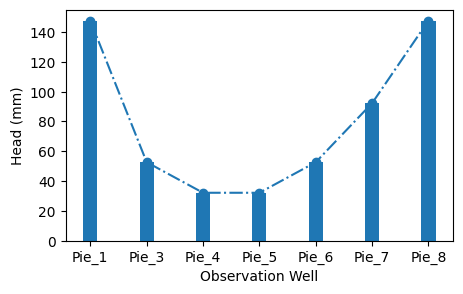

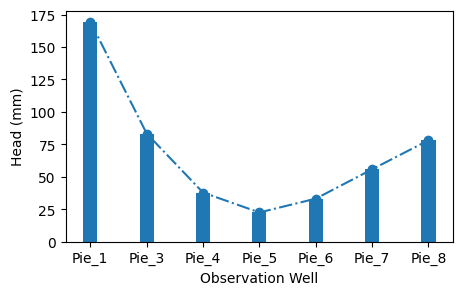

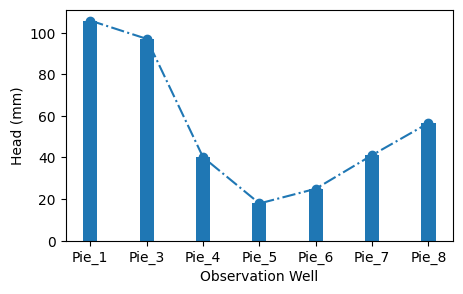

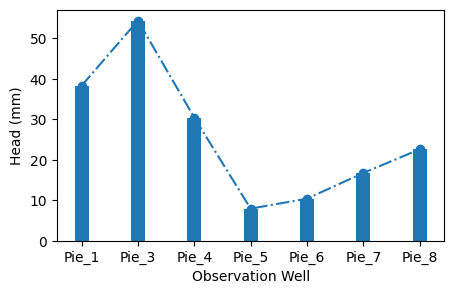

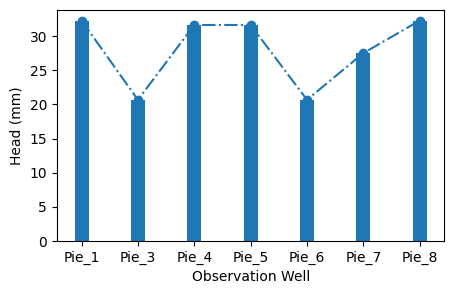

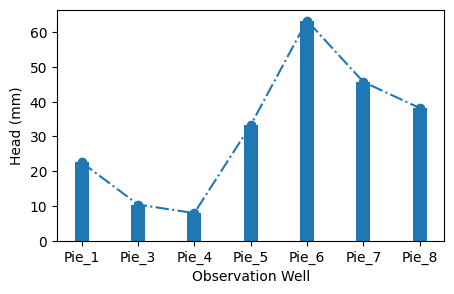

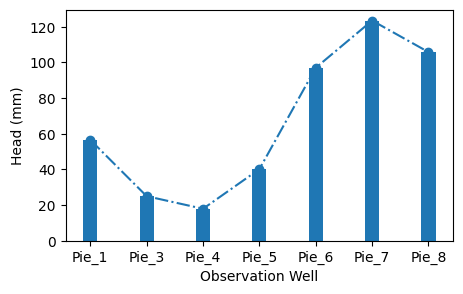

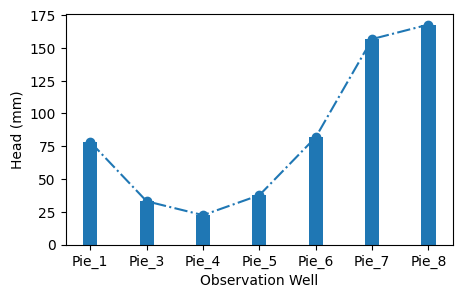

In [ ]:
test_forward.read_stress_FwdObs(init_h = 350)

result_stress_idx= sorted(test_forward.stress_result)

for idx in result_stress_idx:
    
    df = test_forward.stress_result[idx]
    plt.figure(figsize=(5,3))
    plt.bar(df.columns, df.iloc[0], width = 0.25)
    # plt.plot(df.columns, df.iloc[0], '-.o', markersize = 6)
    plt.xlabel("Observation Well")
    plt.ylabel("Head (mm)")
    plt.show()    

# Forward Simulation folder for HT-NN training data

In [5]:
# Create sandbox forward simulation
# Each injection will be a independent events
# Each event contain 1 source well, 8 observations well
# All events keep the same observation well (ob_1~ ob_8)
# HTNN_Sandbox/
# └── forward/
#     └── inj_1/
#     └── inj_2/ 

# Simulation control (unit: mm, sec)
project_name = 'Sandbox_forward'
simulation_control = ('3D', 'steady', 'confined')  # dimension, problem, aquifer

# Geometry control
dx = np.array( [43.5, 25, 20, 20, 20] + [7.5] * 19 + [6, 6, 5.5, 5.5, 6, 6] + [7.5] * 19 + [20, 20, 20, 25, 43.5])
dy = np.array( [31, 20, 20, 20, 10] + [7.5] * 24 + [10, 20, 20, 20, 31])
dz = np.array( [30, 25, 20, 15, 10, 10] + [5] * 11 + [7.5, 7.5] + [10, 10, 10, 25, 30, 35] )

start_coord = (0, 0, 0)         # origin coordinate (x0, y0, z0)
element_num = (54, 34, 25)      # element number in each direction (e_x, e_y, e_z)
element_spacing = (dx, dy, dz)  # element spacing in each direction (len(dx) = e_x-)

# initial condition
init_paras = (350, 0, 0.004, 0.00001, 0.4) # init_h, init_flux, init_K, init_Ss, porosity

# boundary condition
boundary = ('surface', 'UP', 'head')  # method, value, bc_type, bc_value

# injection well info (Each inj_N is a event)
const_rate = 600
inj_time = (0, 600)
inj_1 = ((288.5, 71,  120), 'inj_1', {'rate':const_rate, 'time': inj_time})
inj_2 = ((88.5,  71,  110), 'inj_2', {'rate':const_rate, 'time': inj_time})
inj_3 = ((88.5,  191, 100), 'inj_3', {'rate':const_rate, 'time': inj_time})
inj_4 = ((88.5,  311, 90 ), 'inj_4', {'rate':const_rate, 'time': inj_time})
inj_5 = ((288.5, 311, 120), 'inj_5', {'rate':const_rate, 'time': inj_time})
inj_6 = ((488.5, 311, 110), 'inj_6', {'rate':const_rate, 'time': inj_time})
inj_7 = ((488.5, 191, 100), 'inj_7', {'rate':const_rate, 'time': inj_time})
inj_8 = ((488.5, 71,  90 ), 'inj_8', {'rate':const_rate, 'time': inj_time})

injs = [inj_1, inj_2, inj_3,inj_4, inj_5, inj_6, inj_7, inj_8]

# observation well info (same for all events)
ob_1 = ((188.5, 71,  130), 'Pie_1')
ob_2 = ((88.5, 131,  200), 'Pie_2')
ob_3 = ((88.5, 251,  180), 'Pie_3')
ob_4 = ((188.5, 311, 150), 'Pie_4')
ob_5 = ((388.5, 311, 150), 'Pie_5')
ob_6 = ((488.5, 251, 180), 'Pie_6')
ob_7 = ((488.5, 131, 200), 'Pie_7')
ob_8 = ((388.5, 71,  130), 'Pie_8')

obs = [ob_1, ob_2, ob_3, ob_4, ob_5, ob_6, ob_7, ob_8]

# time info for transient (Not used for steady case)
flag = 'each_time_step'
dt, dt_max, dt_mul, t_max, max_red = (1, 2, 1, 60, 2)
time = (dt, dt_max, dt_mul, t_max, max_red, flag)      
                                

## Create independent event

In [ ]:
# project/
# │
# ├── material/
# │   ├── material_1.dat
# │   ├── material_2.dat
# │   ├── ...
# │   └── material_5.dat
# │
# ├── forward/
# │   │
# │   ├── Event_1/
# │   │   ├── SLE.exe
# │   │   ├── grid.dat
# │   │   ├── node.dat
# │   │   ├── element.dat
# │   │   ├── problem.dat
# │   │   └── ...
# │   │
# │   ├── Event_2/
# │   │   ├── SLE.exe
# │   │   ├── grid.dat
# │   │   └── ...
# │   │
# │   ├── ...
# │   │
# │   └── Event_8/
# │       ├── SLE.exe
# │       ├── grid.dat
# │       └── ...
# │
# └── run_all.py

stress_num = len(injs)
event_name = [f"inj_{i+1}" for i in range(stress_num )]

for i in range(stress_num):
    
    project_name = f"forward_{event_name[i]}"
    folder = Path(os.getcwd()) / "forward" / event_name[i]
    fw_ = sle_io(project_name, folder)

    # Geometry 
    fw_.set_parameters(simulation_control)
    fw_.create_geometry(start_coord, element_num, element_spacing)
    fw_.create_initial(init_paras)
    fw_.create_boundary(boundary)

    # events
    fw_.add_stress(1, time, obs, (injs[i],))
    fw_.create_times()
    fw_.create_source()
    fw_.create_observation()

    # # simulation 
    fw_.create_function()
    fw_.create_simulation()
    fw_.create_problem()
    fw_.write_forward_input()
    
    print("-"*36)

Project: forward_inj_1
Work on folder:C:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\forward\inj_1
Simulation in '3D' case, 'confined' aquifer under 'steady' state
Ready for forward simulation!
------------------------------------
Project: forward_inj_2
Work on folder:C:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\forward\inj_2
Simulation in '3D' case, 'confined' aquifer under 'steady' state
Ready for forward simulation!
------------------------------------
Project: forward_inj_3
Work on folder:C:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\forward\inj_3
Simulation in '3D' case, 'confined' aquifer under 'steady' state
Ready for forward simulation!
------------------------------------
Project: forward_inj_4
Work on folder:C:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\forward\inj_4
Simulation in '3D' case, 'confined' aquifer under 'steady' state
Ready for forward simulation!
------------------------------------
Project: forward_inj_5
Work on folder:C:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\f

In [ ]:
# Run forward simulation by given randomn field id and injection event 

def read_one_stress_FwdObs(event_dir, init_h = None):
    
    header = ['loca', 'well', 'time', 'wlevel','flux_x','flux_y','w_content','solute_concentation','solute_flux', '?']
    df = pd.read_csv(event_dir/"O-FwdObs.dat", header=None,sep=r'\s+', names = header, engine='python')
    df.drop([0], inplace=True)
    df_groupby = df.groupby('well')
        
    df_head = pd.DataFrame()
    well_list = sorted(list(df_groupby.groups), key=len)

    for well_name in well_list:   
        df_well = df_groupby.get_group(well_name)['wlevel']
        df_well.name = well_name
        df_well.reset_index(inplace=True, drop=True)
        
        df_head[well_name] = df_well
    if init_h:
        df_head = df_head.subtract(init_h, axis = 1 )            
                            
    
    return df_head
    
def run_single_case(event_name, field_idx, init_h = None, print_output = None):
    
    project_dir = Path.cwd()
    rf_dir = project_dir/"material"/f"material_{field_idx}.dat"
    event_dir = project_dir/"forward"/f"{event_name}" 
    
    
    # All required DataFrames
    forward_required_files = ["grid.dat", 
                                "material.dat", 
                                "node.dat",
                                "element.dat",
                                "boundary.dat",
                                "bc.dat",
                                "obwell.dat",
                                "problem.dat",
                                "function.dat",
                                "simulation.dat",
                                "time.dat",
                                "sources.dat",
                                "SLE.exe"]

    # Check missing DataFrames
    missing_files = [f for f in forward_required_files if not os.path.exists( event_dir )]
    if missing_files:
        raise FileNotFoundError(f"missing following files\n" +
                                "\n".join(f"  - {file}" for file in missing_files))
    
    # Read random field
    df_rf = pd.read_csv( rf_dir , sep="\t", header = 0 )

    
    # Read material format
    df_material = pd.read_csv( event_dir/'material.dat', sep="\t", header=None )
    
    # Read grid
    total_element_num = np.loadtxt(os.path.join('test_forward', 'grid.dat'))[0].astype(int)

    # Update material
    df_material.columns = ['Kx','Ky','Kz','n','Ss','none1','none2']
    df_material.loc[1:total_element_num, 'Kx'] = df_rf['K'].values
    df_material.loc[1:total_element_num, 'Ky'] = df_rf['K'].values
    df_material.loc[1:total_element_num, 'Kz'] = df_rf['K'].values
    df_material.loc[1:total_element_num, 'Ss']
    df_material.to_csv(event_dir/'material.dat', sep="\t", header=False, index=False)
                
    # Run SLE
    p = Popen( [str(event_dir/'SLE.exe')], cwd = event_dir, stdout=PIPE, stdin=PIPE, stderr=PIPE )

    stdout_data, stderr_data = p.communicate(
        input=b"\n"
    )

    if print_output:
        print(
            stdout_data.decode(
                errors="ignore"
            )
        )
    df_head = read_one_stress_FwdObs(event_dir, init_h)
    
    return df_head

run_single_case("inj_1", 1, init_h = None, print_output = None)

## Test